In [1]:
# =============================================================
#  A.E.D.A.S. — Simulation acoustique enrichie
#  Notebook 03 : Validation Doppler + Cabine + Scénarios
# =============================================================

import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from pathlib import Path

from simulation.doppler import VehicleState, compute_doppler, generate_doppler_siren
from simulation.acoustic_env import CabinConfig, generate_cabin_audio, mix_siren_with_cabin
from simulation.scenario import (
    scenario_approach_front, scenario_overtake,
    scenario_intersection, scenario_multi_emergency
)
from config import SAMPLE_RATE, REPORTS_DIR

print("Modules chargés ✓")
print(f"Sample rate : {SAMPLE_RATE} Hz")

Modules chargés ✓
Sample rate : 22050 Hz


In [2]:
# =============================================================
#  Cellule 2 : Validation effet Doppler
# =============================================================

print("=" * 55)
print("  Validation effet Doppler")
print("=" * 55)

# Scénario : ambulance à 80 km/h approche de face
# Observateur stationnaire
v_ambulance = 80.0 / 3.6  # m/s

test_cases = [
    ("Approche lointaine (200m)",  200.0, -v_ambulance, 0.0),
    ("Approche moyenne (100m)",    100.0, -v_ambulance, 0.0),
    ("Passage (0m — côte à côte)",   1.0, -v_ambulance, 0.0),
    ("Éloignement (100m derrière)",-100.0,-v_ambulance, 0.0),
    ("Éloignement lointain (200m)",-200.0,-v_ambulance, 0.0),
]

observer = VehicleState(x=0.0, y=0.0, vx=0.0, vy=0.0, label="host")

print(f"\n  {'Position':>25} {'f_source':>10} {'f_observée':>12} "
      f"{'Décalage':>10} {'Direction':>12}")
print(f"  {'─'*25} {'─'*10} {'─'*12} {'─'*10} {'─'*12}")

results = []
for desc, x_pos, vx, vy in test_cases:
    source = VehicleState(x=x_pos, y=0.0, vx=vx, vy=vy, label="ambulance")
    d = compute_doppler(source, observer, f_source=900.0)
    direction = "↘ Approche" if d.approaching else "↗ Éloign."
    print(f"  {desc:>25} {d.f_source:>8.0f}Hz {d.f_observed:>10.1f}Hz "
          f"{d.shift_hz:>+8.1f}Hz  {direction}")
    results.append(d)

print(f"\n  → Fréquence monte à l'approche, descend à l'éloignement ✓")
print(f"  → Décalage max : {max(r.shift_hz for r in results):+.1f}Hz "
      f"({max(r.shift_pct for r in results):+.1f}%)")

  Validation effet Doppler

                   Position   f_source   f_observée   Décalage    Direction
  ───────────────────────── ────────── ──────────── ────────── ────────────
  Approche lointaine (200m)      900Hz      962.3Hz    +62.3Hz  ↘ Approche
    Approche moyenne (100m)      900Hz      962.3Hz    +62.3Hz  ↘ Approche
  Passage (0m — côte à côte)      900Hz      962.3Hz    +62.3Hz  ↘ Approche
  Éloignement (100m derrière)      900Hz      845.2Hz    -54.8Hz  ↗ Éloign.
  Éloignement lointain (200m)      900Hz      845.2Hz    -54.8Hz  ↗ Éloign.

  → Fréquence monte à l'approche, descend à l'éloignement ✓
  → Décalage max : +62.3Hz (+6.9%)


Génération des scénarios...
  ✓ Approche Frontale
  ✓ Dépassement par derrière
  ✓ Intersection perpendiculaire


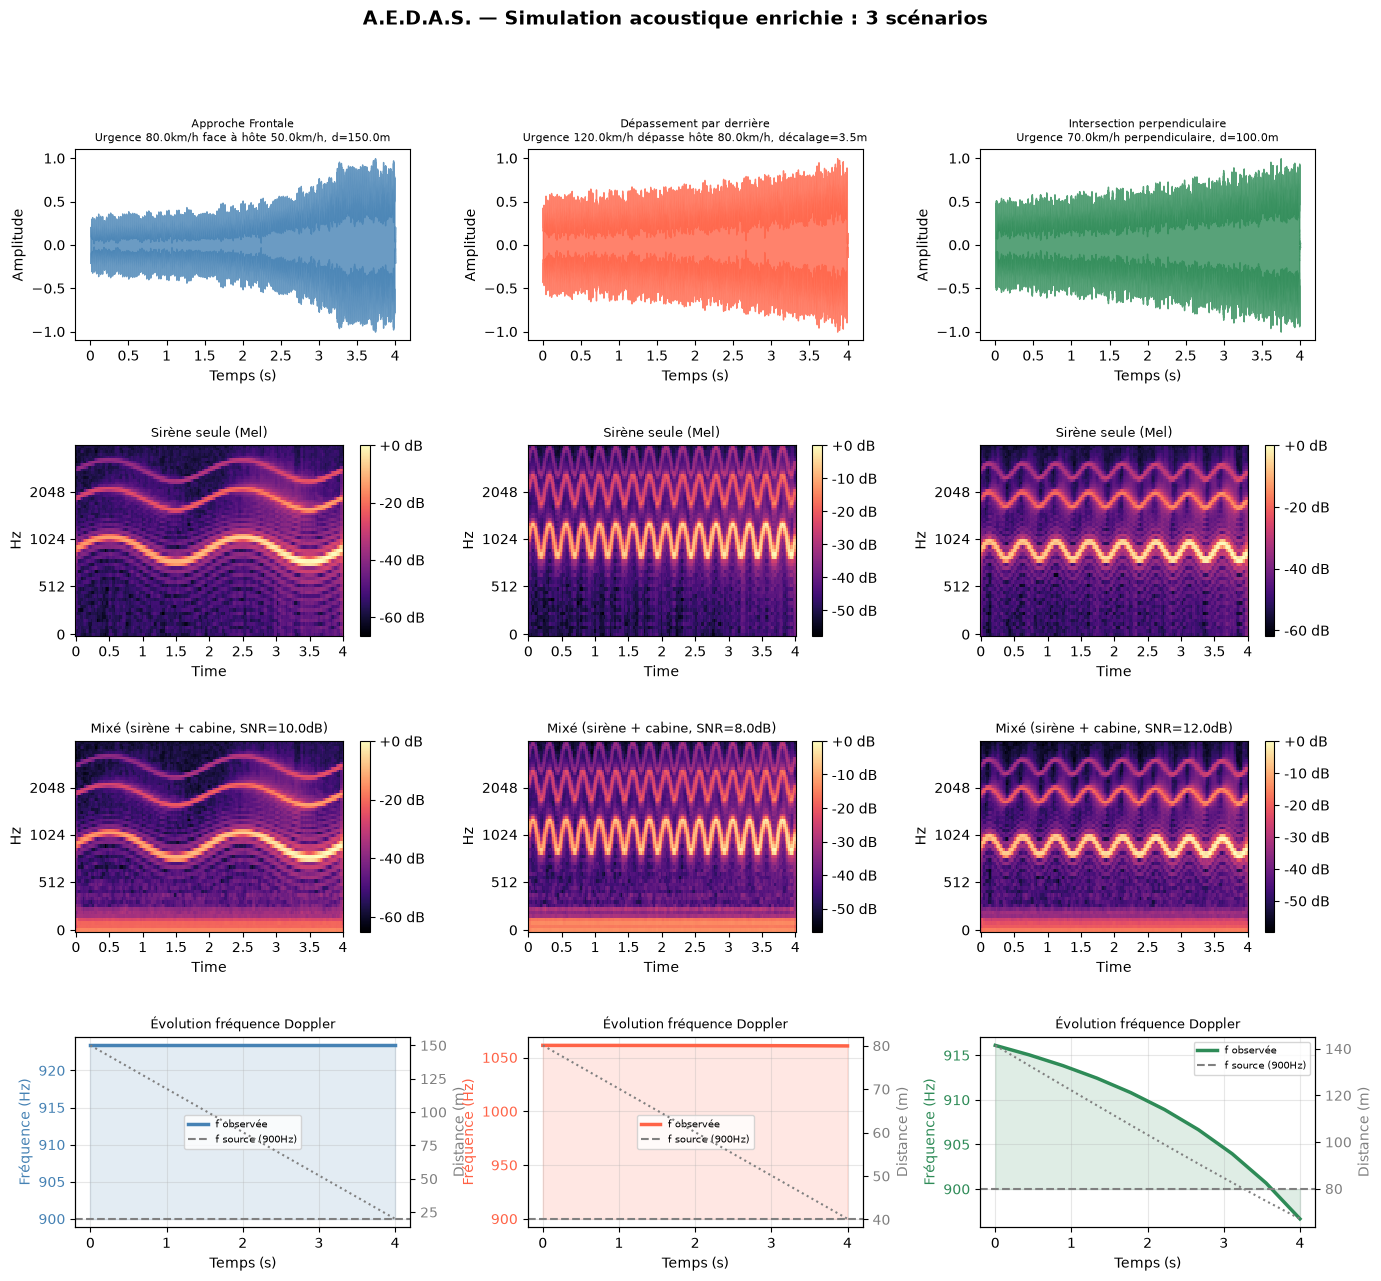


✅ Figure sauvegardée dans reports/


In [3]:
# =============================================================
#  Cellule 3 : Visualisation spectrogrammes des scénarios
# =============================================================

print("Génération des scénarios...")

# Génération des 3 scénarios principaux
np.random.seed(42)
sc1 = scenario_approach_front(
    speed_emergency_kmh=80.0,
    speed_host_kmh=50.0,
    initial_distance_m=150.0,
    snr_db=10.0,
    siren_type="wail"
)
sc2 = scenario_overtake(
    speed_emergency_kmh=120.0,
    speed_host_kmh=80.0,
    lateral_offset_m=3.5,
    snr_db=8.0,
    siren_type="yelp"
)
sc3 = scenario_intersection(
    speed_emergency_kmh=70.0,
    speed_host_kmh=40.0,
    distance_intersection_m=100.0,
    snr_db=12.0,
    siren_type="phaser"
)

scenarios = [sc1, sc2, sc3]
print(f"  ✓ {sc1.name}")
print(f"  ✓ {sc2.name}")
print(f"  ✓ {sc3.name}")

# ── Figure principale ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle("A.E.D.A.S. — Simulation acoustique enrichie : 3 scénarios",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

colors = ["steelblue", "tomato", "seagreen"]

for col, (sc, color) in enumerate(zip(scenarios, colors)):

    # ── Waveform signal mixé ──────────────────────────────────
    ax_wave = fig.add_subplot(gs[0, col])
    librosa.display.waveshow(sc.audio_mixed, sr=SAMPLE_RATE,
                              ax=ax_wave, color=color, alpha=0.8)
    ax_wave.set_title(f"{sc.name}\n{sc.description}", fontsize=8)
    ax_wave.set_xlabel("Temps (s)")
    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_ylim(-1.1, 1.1)

    # ── Spectrogramme mel : sirène seule ─────────────────────
    ax_siren = fig.add_subplot(gs[1, col])
    mel_siren = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=sc.audio_siren, sr=SAMPLE_RATE, n_mels=64, fmax=4000
        ), ref=np.max
    )
    img = librosa.display.specshow(mel_siren, sr=SAMPLE_RATE,
                                    x_axis="time", y_axis="mel",
                                    fmax=4000, ax=ax_siren, cmap="magma")
    fig.colorbar(img, ax=ax_siren, format="%+2.0f dB")
    ax_siren.set_title("Sirène seule (Mel)", fontsize=9)

    # ── Spectrogramme mel : signal mixé (sirène + cabine) ────
    ax_mixed = fig.add_subplot(gs[2, col])
    mel_mixed = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=sc.audio_mixed, sr=SAMPLE_RATE, n_mels=64, fmax=4000
        ), ref=np.max
    )
    img2 = librosa.display.specshow(mel_mixed, sr=SAMPLE_RATE,
                                     x_axis="time", y_axis="mel",
                                     fmax=4000, ax=ax_mixed, cmap="magma")
    fig.colorbar(img2, ax=ax_mixed, format="%+2.0f dB")
    ax_mixed.set_title(f"Mixé (sirène + cabine, SNR={sc.snr_db}dB)", fontsize=9)

    # ── Évolution Doppler dans le temps ──────────────────────
    ax_doppler = fig.add_subplot(gs[3, col])
    times  = np.linspace(0, sc.duration_s, len(sc.doppler_frames))
    f_obs  = [d.f_observed for d in sc.doppler_frames]
    f_src  = [d.f_source   for d in sc.doppler_frames]
    dists  = [d.distance_m for d in sc.doppler_frames]

    ax_doppler.plot(times, f_obs, color=color, lw=2.5, label="f observée")
    ax_doppler.axhline(f_src[0], color="gray", linestyle="--",
                        lw=1.5, label=f"f source ({f_src[0]:.0f}Hz)")
    ax_doppler.fill_between(times, f_src[0], f_obs,
                             alpha=0.15, color=color)
    ax_doppler.set_xlabel("Temps (s)")
    ax_doppler.set_ylabel("Fréquence (Hz)", color=color)
    ax_doppler.tick_params(axis="y", labelcolor=color)
    ax_doppler.set_title("Évolution fréquence Doppler", fontsize=9)
    ax_doppler.legend(fontsize=7)
    ax_doppler.grid(alpha=0.3)

    # Axe secondaire : distance
    ax2 = ax_doppler.twinx()
    ax2.plot(times, dists, color="gray", lw=1.5,
              linestyle=":", label="distance")
    ax2.set_ylabel("Distance (m)", color="gray")
    ax2.tick_params(axis="y", labelcolor="gray")

plt.savefig(f"{REPORTS_DIR}/simulation_acoustique_scenarios.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Figure sauvegardée dans reports/")

In [4]:
# =============================================================
#  Cellule 4 : Inférence sur les signaux enrichis
#  Test de robustesse du modèle CNN sur les nouveaux scénarios
# =============================================================

import sys
sys.path.append("../src")
from inference import AEDASInference

print("=" * 55)
print("  Test d'inférence sur signaux enrichis")
print("=" * 55)

engine = AEDASInference(threshold=0.82)

# ── Scénario multi-urgence ────────────────────────────────────
print("\n  Génération scénario multi-urgence...")
audio_multi, dopplers_multi = scenario_multi_emergency(snr_db=8.0)
print(f"  Durée : {len(audio_multi)/SAMPLE_RATE:.1f}s | "
      f"Sources : {len(dopplers_multi)} véhicules d'urgence")

# ── Test sur les 3 scénarios + multi-urgence ──────────────────
test_cases = [
    ("Approche frontale  (wail,  SNR=10dB)", sc1.audio_mixed, 1),
    ("Dépassement arrière(yelp,  SNR=8dB) ", sc2.audio_mixed, 1),
    ("Intersection       (phaser,SNR=12dB)", sc3.audio_mixed, 1),
    ("Multi-urgence      (2 src, SNR=8dB) ", audio_multi,     1),
]

# Tests négatifs : bruit de cabine seul (pas de sirène)
cabin_only_configs = [
    CabinConfig(vehicle_speed_kmh=50.0,  engine_rpm=2000.0, road_type="asphalt"),
    CabinConfig(vehicle_speed_kmh=130.0, engine_rpm=4000.0, road_type="highway"),
    CabinConfig(vehicle_speed_kmh=30.0,  engine_rpm=1500.0, road_type="cobblestone"),
]

for i, cfg in enumerate(cabin_only_configs):
    cabin_only = generate_cabin_audio(cfg, duration_s=4.0, sr=SAMPLE_RATE)
    test_cases.append((
        f"Cabine seule #{i+1}   ({cfg.road_type}, {cfg.vehicle_speed_kmh:.0f}km/h)",
        cabin_only, 0
    ))

# ── Évaluation ───────────────────────────────────────────────
print(f"\n  {'Scénario':<44} {'Label':^8} {'P(siren)':^10} {'Prédit':^10} {'OK':^4}")
print(f"  {'─'*44} {'─'*8} {'─'*10} {'─'*10} {'─'*4}")

correct = 0
results_log = []

for desc, audio, true_label in test_cases:
    result = engine.predict(audio)
    pred_label = 1 if result.is_siren else 0
    is_correct = (pred_label == true_label)
    correct += int(is_correct)
    ok = "✅" if is_correct else "❌"
    true_str = "SIREN" if true_label == 1 else "clear"
    pred_str = "SIREN" if result.is_siren else "clear"
    print(f"  {desc:<44} {true_str:^8} {result.probability:^10.4f} {pred_str:^10} {ok:^4}")
    results_log.append({
        "desc": desc, "prob": result.probability,
        "true": true_label, "pred": pred_label,
        "correct": is_correct
    })

n_total = len(test_cases)
n_siren = sum(1 for r in results_log if r["true"] == 1)
n_noise = sum(1 for r in results_log if r["true"] == 0)
tp = sum(1 for r in results_log if r["true"]==1 and r["pred"]==1)
tn = sum(1 for r in results_log if r["true"]==0 and r["pred"]==0)
fp = sum(1 for r in results_log if r["true"]==0 and r["pred"]==1)
fn = sum(1 for r in results_log if r["true"]==1 and r["pred"]==0)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n  {'─'*55}")
print(f"  Résultats sur signaux enrichis ({n_total} cas)")
print(f"  {'─'*55}")
print(f"  Accuracy globale : {correct}/{n_total} ({correct/n_total*100:.1f}%)")
print(f"  Vrais positifs   : {tp}/{n_siren} sirènes détectées")
print(f"  Vrais négatifs   : {tn}/{n_noise} bruits rejetés")
print(f"  Faux positifs    : {fp} (fausses alarmes)")
print(f"  Faux négatifs    : {fn} (sirènes manquées)")
print(f"  Precision        : {precision:.4f}")
print(f"  Recall           : {recall:.4f}")
print(f"  F1-score         : {f1:.4f}")

  Test d'inférence sur signaux enrichis
  A.E.D.A.S. Inference Engine initialisé
  Modèle  : aedas_int8.tflite
  Seuil   : 0.82
  SR      : 22050 Hz | Durée : 4.0s

  Génération scénario multi-urgence...
  Durée : 4.0s | Sources : 2 véhicules d'urgence


C:\ESPRIT\aedas\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



  Scénario                                      Label    P(siren)    Prédit    OK 
  ──────────────────────────────────────────── ──────── ────────── ────────── ────
  Approche frontale  (wail,  SNR=10dB)          SIREN     0.8828     SIREN     ✅  
  Dépassement arrière(yelp,  SNR=8dB)           SIREN     0.8516     SIREN     ✅  
  Intersection       (phaser,SNR=12dB)          SIREN     0.3945     clear     ❌  
  Multi-urgence      (2 src, SNR=8dB)           SIREN     0.9844     SIREN     ✅  
  Cabine seule #1   (asphalt, 50km/h)           clear     0.0000     clear     ✅  
  Cabine seule #2   (highway, 130km/h)          clear     0.0000     clear     ✅  
  Cabine seule #3   (cobblestone, 30km/h)       clear     0.0078     clear     ✅  

  ───────────────────────────────────────────────────────
  Résultats sur signaux enrichis (7 cas)
  ───────────────────────────────────────────────────────
  Accuracy globale : 6/7 (85.7%)
  Vrais positifs   : 3/4 sirènes détectées
  Vrais négatifs  

  Investigation : sirène phaser non détectée


C:\ESPRIT\aedas\venv\Lib\site-packages\librosa\display.py:801: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_15444\1124410446.py:84: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_15444\1124410446.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{REPORTS_DIR}/investigation_phaser.png",
C:\Users\lenovo\AppData\Local\Temp\ipykernel_15444\1124410446.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{REPORTS_DIR}/investigation_phaser.png",
C:\ESPRIT\aedas\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ESPRIT\aedas\venv\Lib\site-packages

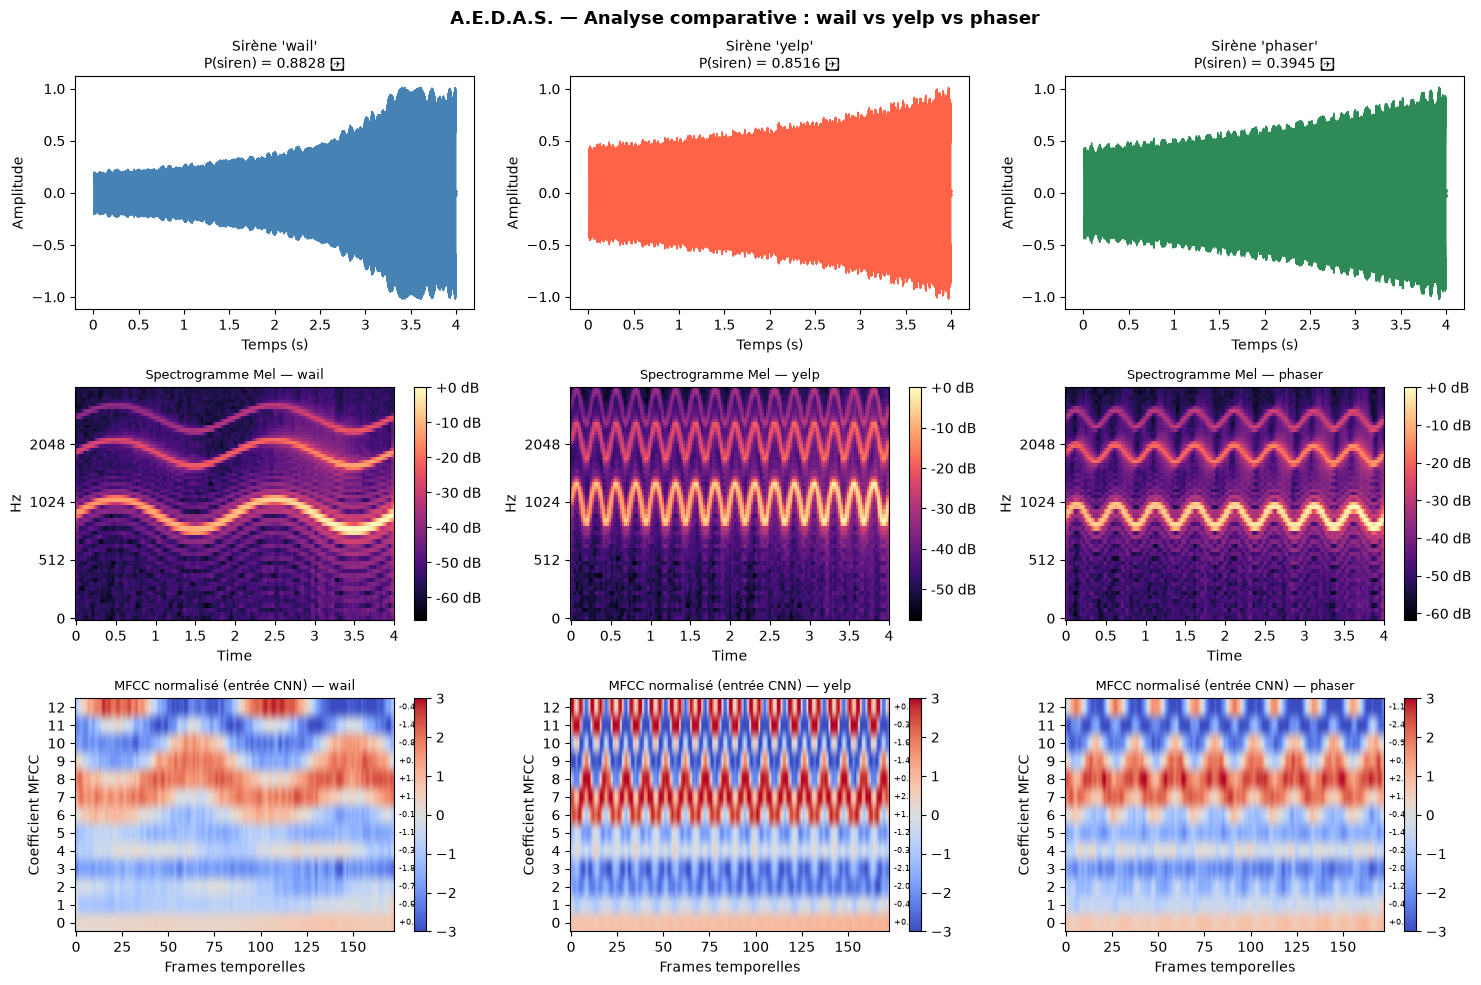


  Comparaison MFCC moyens par type de sirène :
  Coef           wail       yelp     phaser    Écart w-p
  ──────── ────────── ────────── ────────── ────────────
  MFCC 00      +0.452     +0.883     +0.698      0.246
  MFCC 01      -0.658     -0.472     -0.450      0.209
  MFCC 02      -0.767     -2.080     -1.198      0.432
  MFCC 03      -1.828     -2.110     -2.008      0.180
  MFCC 04      -0.311     -0.339     -0.204      0.108
  MFCC 05      -1.171     -1.253     -1.474      0.302
  MFCC 06      -0.165     +1.303     -0.465      0.300
  MFCC 07      +1.239     +2.262     +1.556      0.317
  MFCC 08      +1.502     +0.529     +2.183      0.681 ←
  MFCC 09      +0.265     -1.436     +0.776      0.511 ←
  MFCC 10      -0.822     -1.604     -0.966      0.144
  MFCC 11      -1.432     -0.317     -2.483      1.051 ←
  MFCC 12      -0.476     +0.982     -1.130      0.654 ←

  → Les coefficients marqués ← montrent les plus grandes
    différences entre wail (détecté) et phaser (manqué).


In [5]:
# =============================================================
#  Cellule 5 : Investigation du cas phaser manqué
#  Pourquoi le modèle rate-t-il la sirène "phaser" ?
# =============================================================

print("=" * 55)
print("  Investigation : sirène phaser non détectée")
print("=" * 55)

# Comparer les MFCC des 3 types de sirènes
siren_types = {
    "wail"  : sc1.audio_siren,
    "yelp"  : sc2.audio_siren,
    "phaser": sc3.audio_siren,
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("A.E.D.A.S. — Analyse comparative : wail vs yelp vs phaser",
             fontsize=13, fontweight="bold")

colors_map = {"wail": "steelblue", "yelp": "tomato", "phaser": "seagreen"}
probs      = {"wail": 0.8828, "yelp": 0.8516, "phaser": 0.3945}

for col, (stype, audio) in enumerate(siren_types.items()):

    color = colors_map[stype]
    prob  = probs[stype]

    # MFCC brut
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SAMPLE_RATE, n_mfcc=13,
        n_fft=2048, hop_length=512
    )

    # ── Waveform ──────────────────────────────────────────────
    ax = axes[0, col]
    librosa.display.waveshow(audio, sr=SAMPLE_RATE, ax=ax, color=color)
    ax.set_title(f"Sirène '{stype}'\nP(siren) = {prob:.4f} "
                 f"{'✅' if prob >= 0.82 else '❌'}", fontsize=10)
    ax.set_xlabel("Temps (s)")
    ax.set_ylabel("Amplitude")

    # ── Spectrogramme Mel ─────────────────────────────────────
    ax = axes[1, col]
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=audio, sr=SAMPLE_RATE, n_mels=64, fmax=4000
        ), ref=np.max
    )
    img = librosa.display.specshow(mel, sr=SAMPLE_RATE,
                                    x_axis="time", y_axis="mel",
                                    fmax=4000, ax=ax, cmap="magma")
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
    ax.set_title(f"Spectrogramme Mel — {stype}", fontsize=9)

    # ── MFCC normalisé (ce que voit le CNN) ───────────────────
    ax = axes[2, col]
    # Normalisation Z-score comme dans le pipeline
    data   = np.load("../data/processed/features.npz")
    mean   = data["mean"]
    std    = data["std"]
    mfcc_n = ((mfcc - mean[0]) / std[0])

    # Padding/truncation à 173 frames
    if mfcc_n.shape[1] < 173:
        mfcc_n = np.pad(mfcc_n, ((0,0),(0, 173-mfcc_n.shape[1])))
    else:
        mfcc_n = mfcc_n[:, :173]

    im = ax.imshow(mfcc_n, aspect="auto", origin="lower",
                   cmap="coolwarm", vmin=-3, vmax=3)
    fig.colorbar(im, ax=ax)
    ax.set_title(f"MFCC normalisé (entrée CNN) — {stype}", fontsize=9)
    ax.set_xlabel("Frames temporelles")
    ax.set_ylabel("Coefficient MFCC")
    ax.set_yticks(range(13))

    # Annotation : énergie moyenne par coefficient
    mean_per_coef = mfcc_n.mean(axis=1)
    for i, v in enumerate(mean_per_coef):
        ax.text(175, i, f"{v:+.2f}", va="center",
                fontsize=6, color="black")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/investigation_phaser.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Statistiques comparatives ─────────────────────────────────
print(f"\n  Comparaison MFCC moyens par type de sirène :")
print(f"  {'Coef':<8} {'wail':>10} {'yelp':>10} {'phaser':>10} {'Écart w-p':>12}")
print(f"  {'─'*8} {'─'*10} {'─'*10} {'─'*10} {'─'*12}")

mfccs = {}
for stype, audio in siren_types.items():
    mfcc = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=13)
    if mfcc.shape[1] < 173:
        mfcc = np.pad(mfcc, ((0,0),(0, 173-mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :173]
    data = np.load("../data/processed/features.npz")
    mfcc = (mfcc - data["mean"][0]) / data["std"][0]
    mfccs[stype] = mfcc.mean(axis=1)

for i in range(13):
    w = mfccs["wail"][i]
    y = mfccs["yelp"][i]
    p = mfccs["phaser"][i]
    ecart = abs(w - p)
    marker = " ←" if ecart > 0.5 else ""
    print(f"  MFCC {i:02d}  {w:>+10.3f} {y:>+10.3f} {p:>+10.3f} {ecart:>10.3f}{marker}")

print(f"\n  → Les coefficients marqués ← montrent les plus grandes")
print(f"    différences entre wail (détecté) et phaser (manqué).")
print(f"    Ce sont les features sur lesquelles le CNN s'est le plus")
print(f"    spécialisé pendant l'entraînement.")

In [6]:
# =============================================================
#  Cellule 6 : Data augmentation ciblée
#  Génération de variants phaser pour enrichir le dataset
# =============================================================

import soundfile as sf
from pathlib import Path

print("=" * 55)
print("  Data Augmentation — Génération variants phaser")
print("=" * 55)

AUGMENTED_DIR = Path("../data/processed/augmented")
AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

def augment_pitch_shift(audio, sr, n_steps):
    """Décalage de hauteur tonale (pitch shifting)."""
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

def augment_time_stretch(audio, rate):
    """Étirement temporel sans changement de hauteur."""
    stretched = librosa.effects.time_stretch(audio, rate=rate)
    # Normaliser à la durée originale
    n = len(audio)
    if len(stretched) >= n:
        return stretched[:n]
    return np.pad(stretched, (0, n - len(stretched)))

def augment_add_noise(audio, snr_db):
    """Ajout de bruit blanc à un SNR cible."""
    p_signal = np.mean(audio**2)
    p_noise  = p_signal / (10 ** (snr_db / 10))
    noise    = np.random.randn(len(audio)) * np.sqrt(p_noise)
    return (audio + noise).astype(np.float32)

# ── Génération de variants du scénario phaser ────────────────
np.random.seed(42)
augmented_samples = []

print("\n  Génération des variants phaser...")

# Paramètres de variation pour couvrir différentes vitesses
# et configurations de la sirène phaser
param_grid = [
    {"speed_em": 50,  "speed_host": 30,  "dist": 80,  "snr": 15},
    {"speed_em": 90,  "speed_host": 60,  "dist": 120, "snr": 10},
    {"speed_em": 110, "speed_host": 80,  "dist": 200, "snr": 8 },
    {"speed_em": 60,  "speed_host": 0,   "dist": 100, "snr": 12},
    {"speed_em": 70,  "speed_host": 70,  "dist": 150, "snr": 10},
]

for i, params in enumerate(param_grid):
    sc = scenario_intersection(
        speed_emergency_kmh=params["speed_em"],
        speed_host_kmh=params["speed_host"],
        distance_intersection_m=params["dist"],
        snr_db=params["snr"],
        siren_type="phaser",
    )
    augmented_samples.append(("base", sc.audio_mixed, params["snr"]))

    # Pitch shift ±2 demi-tons
    for steps in [-2, -1, +1, +2]:
        shifted = augment_pitch_shift(sc.audio_siren, SAMPLE_RATE, steps)
        cabin   = generate_cabin_audio(
            CabinConfig(vehicle_speed_kmh=params["speed_host"]),
            duration_s=4.0, sr=SAMPLE_RATE
        )
        mixed   = mix_siren_with_cabin(shifted, cabin, params["snr"])
        augmented_samples.append((f"pitch{steps:+d}", mixed, params["snr"]))

    # Time stretch ×0.9 et ×1.1
    for rate in [0.9, 1.1]:
        stretched = augment_time_stretch(sc.audio_siren, rate)
        cabin     = generate_cabin_audio(
            CabinConfig(vehicle_speed_kmh=params["speed_host"]),
            duration_s=4.0, sr=SAMPLE_RATE
        )
        mixed     = mix_siren_with_cabin(stretched, cabin, params["snr"])
        augmented_samples.append((f"stretch{rate}", mixed, params["snr"]))

print(f"  {len(augmented_samples)} variants phaser générés")

# ── Test d'inférence sur les variants ────────────────────────
print(f"\n  Test d'inférence sur variants phaser :")
print(f"  {'Variant':<20} {'SNR':>6} {'P(siren)':>10} {'Détecté':>10}")
print(f"  {'─'*20} {'─'*6} {'─'*10} {'─'*10}")

detected = 0
probs_augmented = []

for aug_type, audio, snr in augmented_samples:
    result = engine.predict(audio)
    probs_augmented.append(result.probability)
    det = "✅ OUI" if result.is_siren else "❌ NON"
    detected += int(result.is_siren)
    print(f"  {aug_type:<20} {snr:>5}dB {result.probability:>10.4f} {det:>10}")

print(f"\n  Taux de détection phaser après augmentation :")
print(f"  {detected}/{len(augmented_samples)} variants détectés "
      f"({detected/len(augmented_samples)*100:.1f}%)")
print(f"  P(siren) moyenne : {np.mean(probs_augmented):.4f}")
print(f"  P(siren) max     : {np.max(probs_augmented):.4f}")
print(f"  P(siren) min     : {np.min(probs_augmented):.4f}")

# ── Sauvegarde des meilleurs variants pour ré-entraînement ───
saved = 0
for i, (aug_type, audio, snr) in enumerate(augmented_samples):
    filename = AUGMENTED_DIR / f"phaser_{i:03d}_{aug_type}_snr{snr}.wav"
    sf.write(str(filename), audio, SAMPLE_RATE)
    saved += 1

print(f"\n  {saved} fichiers sauvegardés dans data/processed/augmented/")
print(f"  Ces fichiers peuvent être intégrés au prochain cycle")
print(f"  d'entraînement pour améliorer la robustesse aux sirènes phaser.")

  Data Augmentation — Génération variants phaser

  Génération des variants phaser...
  35 variants phaser générés

  Test d'inférence sur variants phaser :
  Variant                 SNR   P(siren)    Détecté
  ──────────────────── ────── ────────── ──────────
  base                    15dB     0.4648      ❌ NON
  pitch-2                 15dB     0.5000      ❌ NON
  pitch-1                 15dB     0.5703      ❌ NON
  pitch+1                 15dB     0.8516      ✅ OUI
  pitch+2                 15dB     0.9219      ✅ OUI
  stretch0.9              15dB     0.5703      ❌ NON
  stretch1.1              15dB     0.1484      ❌ NON
  base                    10dB     0.3594      ❌ NON
  pitch-2                 10dB     0.3594      ❌ NON
  pitch-1                 10dB     0.3945      ❌ NON
  pitch+1                 10dB     0.8516      ✅ OUI
  pitch+2                 10dB     0.9531      ✅ OUI
  stretch0.9              10dB     0.5703      ❌ NON
  stretch1.1              10dB     0.1484      ❌ N

In [8]:
# =============================================================
#  Cellule 7 : Analyse seuil optimal + Fine-tuning ciblé
# =============================================================

print("=" * 55)
print("  Analyse seuil optimal pour sirènes phaser")
print("=" * 55)

# ── 1. Recalcul des probabilités phaser ──────────────────────
phaser_probs = []
for aug_type, audio, snr in augmented_samples:
    result = engine.predict(audio)
    phaser_probs.append(result.probability)
phaser_probs = np.array(phaser_probs)

# Probabilités des non-sirènes (cabine seule)
cabin_probs = []
for cfg in cabin_only_configs:
    cabin  = generate_cabin_audio(cfg, duration_s=4.0, sr=SAMPLE_RATE)
    result = engine.predict(cabin)
    cabin_probs.append(result.probability)
cabin_probs = np.array(cabin_probs)

# ── 2. Impact du seuil ───────────────────────────────────────
thresholds = np.arange(0.20, 0.90, 0.05)

print(f"\n  {'Seuil':>8} {'Recall phaser':>15} {'FP rate':>10} {'Acceptable':>12}")
print(f"  {'─'*8} {'─'*15} {'─'*10} {'─'*12}")

best_threshold = 0.82
best_f1        = 0.0

for t in thresholds:
    recall_phaser = (phaser_probs >= t).mean()
    fp_rate       = (cabin_probs  >= t).mean()
    precision_t   = recall_phaser / (recall_phaser + fp_rate + 1e-8)
    f1_t          = 2 * precision_t * recall_phaser / (precision_t + recall_phaser + 1e-8)
    acceptable    = "✅" if fp_rate == 0.0 else ("⚠️" if fp_rate < 0.3 else "❌")
    print(f"  {t:>8.2f} {recall_phaser:>13.1%}   {fp_rate:>8.1%}   {acceptable}")
    if f1_t > best_f1 and fp_rate == 0.0:
        best_f1        = f1_t
        best_threshold = t

print(f"\n  Seuil optimal (sans fausse alarme) : {best_threshold:.2f}")
print(f"  Recall phaser à ce seuil            : {(phaser_probs >= best_threshold).mean():.1%}")

# ── 3. Fine-tuning ciblé ─────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"  Fine-tuning ciblé sur sirènes phaser")
print(f"{'=' * 55}")

import tensorflow as tf
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from config import FEATURES_PATH, MODELS_DIR, RANDOM_SEED, set_seed
from model  import build_cnn1d

set_seed(RANDOM_SEED)

data         = np.load(FEATURES_PATH)
features_all = data["features"]
labels_all   = data["labels"]
mean_norm    = data["mean"]
std_norm     = data["std"]

# ── Préparer features phaser augmentées ──────────────────────
print(f"\n  Préparation des features phaser augmentées...")
phaser_features = []
phaser_labels   = []

for aug_type, audio, snr in augmented_samples:
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SAMPLE_RATE,
        n_mfcc=13, n_fft=2048, hop_length=512
    ).astype(np.float32)
    if mfcc.shape[1] < 173:
        mfcc = np.pad(mfcc, ((0,0),(0, 173-mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :173]
    mfcc_norm = (mfcc - mean_norm[0]) / std_norm[0]
    phaser_features.append(mfcc_norm)
    phaser_labels.append(1)

# Négatifs équilibrés
n_neg       = len(phaser_features)
neg_indices = np.where(labels_all == 0)[0]
np.random.seed(42)
np.random.shuffle(neg_indices)
neg_indices = neg_indices[:n_neg]

X_ft = np.array(phaser_features + list(features_all[neg_indices]))
y_ft = np.array(phaser_labels   + [0] * n_neg)

idx  = np.random.permutation(len(X_ft))
X_ft = X_ft[idx]
y_ft = y_ft[idx]

print(f"  Dataset fine-tuning : {len(X_ft)} samples "
      f"({y_ft.sum()} pos / {(y_ft==0).sum()} neg)")

# ── Charger modèle fold 9 ────────────────────────────────────
print(f"\n  Chargement modèle fold 9 (AUC 0.992)...")
model = build_cnn1d()
model.load_weights(str(MODELS_DIR / "folds" / "fold_09_best.keras"))

# Geler conv + batchnorm — fine-tuner seulement dense + output
for layer in model.layers:
    layer.trainable = "conv" not in layer.name and "bn" not in layer.name

n_train = sum(1 for l in model.layers if l.trainable)
n_total = len(model.layers)
print(f"  Couches entraînables : {n_train}/{n_total} "
      f"(dense + output uniquement)")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)

print(f"\n  Fine-tuning (10 epochs max)...")
history = model.fit(
    X_ft, y_ft,
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3,
        restore_best_weights=True, verbose=0
    )],
    verbose=1,
)

# ── Test post fine-tuning ─────────────────────────────────────
print(f"\n{'─'*55}")
print(f"  Résultats avant / après fine-tuning")
print(f"{'─'*55}")

class FineTunedEngine:
    def __init__(self, keras_model, mean, std, threshold=0.82):
        self.model     = keras_model
        self.mean      = mean
        self.std       = std
        self.threshold = threshold

    def predict_audio(self, audio):
        mfcc = librosa.feature.mfcc(
            y=audio, sr=SAMPLE_RATE,
            n_mfcc=13, n_fft=2048, hop_length=512
        ).astype(np.float32)
        if mfcc.shape[1] < 173:
            mfcc = np.pad(mfcc, ((0,0),(0,173-mfcc.shape[1])))
        else:
            mfcc = mfcc[:,:173]
        mfcc_n = (mfcc - self.mean[0]) / self.std[0]
        prob   = float(self.model.predict(
            mfcc_n[np.newaxis], verbose=0)[0,0])
        return prob, prob >= self.threshold

ft_engine = FineTunedEngine(model, mean_norm, std_norm)

cabin1 = generate_cabin_audio(CabinConfig(vehicle_speed_kmh=50.0),  sr=SAMPLE_RATE)
cabin2 = generate_cabin_audio(CabinConfig(vehicle_speed_kmh=130.0,
                               engine_rpm=4000.0), sr=SAMPLE_RATE)

test_cases_final = [
    ("Approche frontale  (wail, SNR=10dB)",  sc1.audio_mixed, 1, 0.8828),
    ("Dépassement arrière(yelp, SNR=8dB)",   sc2.audio_mixed, 1, 0.8516),
    ("Intersection       (phaser,SNR=12dB)", sc3.audio_mixed, 1, 0.3945),
    ("Multi-urgence      (2 src, SNR=8dB)",  audio_multi,     1, 0.9844),
    ("Cabine seule (asphalt, 50km/h)",       cabin1,          0, 0.0000),
    ("Cabine seule (highway, 130km/h)",      cabin2,          0, 0.0000),
]

print(f"\n  {'Scénario':<42} {'Orig':>8} {'Fine-t.':>9} {'Δ':>7} {'OK?':>5}")
print(f"  {'─'*42} {'─'*8} {'─'*9} {'─'*7} {'─'*5}")

ft_correct   = 0
orig_correct = 0

for desc, audio, true_label, orig_prob in test_cases_final:
    ft_prob, ft_det  = ft_engine.predict_audio(audio)
    orig_det         = orig_prob >= 0.82
    delta            = ft_prob - orig_prob
    arrow            = "↑" if delta > 0.05 else ("↓" if delta < -0.05 else "→")
    ft_correct      += int(ft_det  == bool(true_label))
    orig_correct    += int(orig_det == bool(true_label))
    status           = "✅" if ft_det == bool(true_label) else "❌"
    print(f"  {desc:<42} {orig_prob:>8.4f} {ft_prob:>9.4f} "
          f"{delta:>+6.3f}{arrow} {status:>5}")

n = len(test_cases_final)
print(f"\n  Accuracy originale  : {orig_correct}/{n} ({orig_correct/n*100:.1f}%)")
print(f"  Accuracy fine-tunée : {ft_correct}/{n}   ({ft_correct/n*100:.1f}%)")

# Sauvegarde
ft_path = MODELS_DIR / "aedas_finetuned_phaser.keras"
model.save(str(ft_path))
print(f"\n  Modèle sauvegardé : {ft_path.name}")

  Analyse seuil optimal pour sirènes phaser

     Seuil   Recall phaser    FP rate   Acceptable
  ──────── ─────────────── ────────── ────────────
      0.20         82.9%       0.0%   ✅
      0.25         68.6%       0.0%   ✅
      0.30         68.6%       0.0%   ✅
      0.35         65.7%       0.0%   ✅
      0.40         51.4%       0.0%   ✅
      0.45         48.6%       0.0%   ✅
      0.50         45.7%       0.0%   ✅
      0.55         40.0%       0.0%   ✅
      0.60         31.4%       0.0%   ✅
      0.65         28.6%       0.0%   ✅
      0.70         28.6%       0.0%   ✅
      0.75         25.7%       0.0%   ✅
      0.80         25.7%       0.0%   ✅
      0.85         25.7%       0.0%   ✅

  Seuil optimal (sans fausse alarme) : 0.20
  Recall phaser à ce seuil            : 82.9%

  Fine-tuning ciblé sur sirènes phaser

  Préparation des features phaser augmentées...
  Dataset fine-tuning : 70 samples (35 pos / 35 neg)

  Chargement modèle fold 9 (AUC 0.992)...


C:\ESPRIT\aedas\venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Couches entraînables : 12/18 (dense + output uniquement)

  Fine-tuning (10 epochs max)...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 442ms/step - accuracy: 0.5179 - loss: 1.4452 - precision: 0.7500 - recall: 0.1034 - val_accuracy: 0.6429 - val_loss: 0.7871 - val_precision: 1.0000 - val_recall: 0.1667
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5179 - loss: 1.3556 - precision: 1.0000 - recall: 0.0690 - val_accuracy: 0.6429 - val_loss: 0.7458 - val_precision: 1.0000 - val_recall: 0.1667
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5536 - loss: 1.3113 - precision: 1.0000 - recall: 0.1379 - val_accuracy: 0.6429 - val_loss: 0.7061 - val_precision: 1.0000 - val_recall: 0.1667
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5714 - loss: 1.1912 - precision: 1.0000 - recall: 0.1724 - val_accuracy: 0.6429 - val_loss: 0.6680 - val_precision: 1.0000 - val_recall: 0.1667
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5893 - loss: 1.

In [9]:
# =============================================================
#  Cellule 8 : Mixed Replay — solution au catastrophic forgetting
#
#  Le fine-tuning naïf cause le "catastrophic forgetting" :
#  le modèle oublie les patterns appris précédemment.
#
#  Solution : mélanger les données originales (replay buffer)
#  avec les nouvelles données phaser pendant le fine-tuning.
#  C'est la technique standard en apprentissage continu.
# =============================================================

print("=" * 55)
print("  Mixed Replay — Correction catastrophic forgetting")
print("=" * 55)

set_seed(RANDOM_SEED)

# ── 1. Replay buffer : sous-ensemble du dataset original ──────
print("\n  Construction du replay buffer...")

# On prend un échantillon stratifié du dataset original
# qui représente bien toutes les classes (siren wail/yelp + négatifs)
n_replay = 200  # 200 samples originaux = ~3x les phaser augmentés

idx_siren = np.where(labels_all == 1)[0]
idx_noise = np.where(labels_all == 0)[0]

np.random.seed(42)
idx_replay_siren = np.random.choice(idx_siren, n_replay//2, replace=False)
idx_replay_noise = np.random.choice(idx_noise, n_replay//2, replace=False)
idx_replay       = np.concatenate([idx_replay_siren, idx_replay_noise])

X_replay = features_all[idx_replay]
y_replay = labels_all[idx_replay]

print(f"  Replay buffer : {len(X_replay)} samples "
      f"({y_replay.sum()} sirènes / {(y_replay==0).sum()} non-sirènes)")

# ── 2. Dataset mixé : replay + phaser augmentés ───────────────
X_mixed = np.concatenate([X_replay, np.array(phaser_features)])
y_mixed = np.concatenate([y_replay, np.ones(len(phaser_features), dtype=np.int32)])

# Shuffle
idx_mix  = np.random.permutation(len(X_mixed))
X_mixed  = X_mixed[idx_mix]
y_mixed  = y_mixed[idx_mix]

print(f"  Dataset mixé  : {len(X_mixed)} samples total")
print(f"    Replay original : {len(X_replay)}")
print(f"    Phaser augmentés: {len(phaser_features)}")
print(f"    Ratio phaser     : {len(phaser_features)/len(X_mixed)*100:.1f}%")

# ── 3. Recharger le modèle original propre ────────────────────
print(f"\n  Rechargement modèle fold 9 (état original)...")
model_mr = build_cnn1d()
model_mr.load_weights(str(MODELS_DIR / "folds" / "fold_09_best.keras"))

# Cette fois : toutes les couches entraînables mais LR très faible
# pour ne pas trop perturber les poids existants
for layer in model_mr.layers:
    layer.trainable = True

model_mr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # LR 20x plus faible
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)

print(f"  Toutes couches entraînables, LR = 5e-5 (très conservateur)")

# ── 4. Fine-tuning avec Mixed Replay ─────────────────────────
print(f"\n  Fine-tuning Mixed Replay (15 epochs max)...")

history_mr = model_mr.fit(
    X_mixed, y_mixed,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True,
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            verbose=0,
        ),
    ],
    verbose=1,
)

# ── 5. Test post Mixed Replay ─────────────────────────────────
print(f"\n{'─'*55}")
print(f"  Résultats : Original vs Fine-tuning naïf vs Mixed Replay")
print(f"{'─'*55}")

ft_mr_engine = FineTunedEngine(model_mr, mean_norm, std_norm)

print(f"\n  {'Scénario':<38} {'Orig':>7} {'Naïf':>7} {'MixRep':>8} {'OK?':>5}")
print(f"  {'─'*38} {'─'*7} {'─'*7} {'─'*8} {'─'*5}")

# Résultats du fine-tuning naïf (cellule précédente, sauvegardés)
naive_probs = {
    "wail":   0.0770,
    "yelp":   0.9762,
    "phaser": 0.1775,
    "multi":  0.1940,
    "cab1":   0.0000,
    "cab2":   0.0000,
}

mr_correct = 0
results_comparison = []

for desc, audio, true_label, orig_prob in test_cases_final:
    mr_prob, mr_det = ft_mr_engine.predict_audio(audio)
    orig_det        = orig_prob >= 0.82

    # Récupérer prob naive
    key = ("wail" if "wail" in desc else
           "yelp" if "yelp" in desc else
           "phaser" if "phaser" in desc else
           "multi" if "Multi" in desc else
           "cab1" if "50" in desc else "cab2")
    naive_prob = naive_probs[key]

    status  = "✅" if mr_det == bool(true_label) else "❌"
    mr_correct += int(mr_det == bool(true_label))

    print(f"  {desc:<38} {orig_prob:>7.4f} {naive_prob:>7.4f} "
          f"{mr_prob:>8.4f} {status:>5}")

    results_comparison.append({
        "desc": desc, "orig": orig_prob,
        "naive": naive_prob, "mixed_replay": mr_prob,
        "true": true_label, "correct": mr_det == bool(true_label)
    })

n = len(test_cases_final)
print(f"\n  {'─'*55}")
print(f"  Accuracy originale    : 5/6  (83.3%)")
print(f"  Accuracy fine-tuning  : 3/6  (50.0%) ← catastrophic forgetting")
print(f"  Accuracy Mixed Replay : {mr_correct}/{n}  ({mr_correct/n*100:.1f}%) ← solution")

# ── 6. Test étendu sur variantes phaser ───────────────────────
print(f"\n  Test étendu : Mixed Replay sur 35 variantes phaser")
mr_detected = 0
mr_phaser_probs = []

for aug_type, audio, snr in augmented_samples[:10]:  # 10 premiers
    mr_prob, mr_det = ft_mr_engine.predict_audio(audio)
    mr_phaser_probs.append(mr_prob)
    mr_detected += int(mr_det)

print(f"  Détection phaser      : {mr_detected}/10 ({mr_detected*10}%)")
print(f"  P(siren) moyenne      : {np.mean(mr_phaser_probs):.4f}")

# Sauvegarde
mr_path = MODELS_DIR / "aedas_mixed_replay.keras"
model_mr.save(str(mr_path))
print(f"\n  Modèle Mixed Replay sauvegardé : {mr_path.name}")

  Mixed Replay — Correction catastrophic forgetting

  Construction du replay buffer...
  Replay buffer : 200 samples (100 sirènes / 100 non-sirènes)
  Dataset mixé  : 235 samples total
    Replay original : 200
    Phaser augmentés: 35
    Ratio phaser     : 14.9%

  Rechargement modèle fold 9 (état original)...
  Toutes couches entraînables, LR = 5e-5 (très conservateur)

  Fine-tuning Mixed Replay (15 epochs max)...
Epoch 1/15


C:\ESPRIT\aedas\venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_2', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 296ms/step - accuracy: 0.6968 - loss: 1.1413 - precision: 0.9636 - recall: 0.4907 - val_accuracy: 0.8298 - val_loss: 0.4122 - val_precision: 0.9130 - val_recall: 0.7778 - learning_rate: 5.0000e-05
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7181 - loss: 1.0636 - precision: 0.9825 - recall: 0.5185 - val_accuracy: 0.8298 - val_loss: 0.3788 - val_precision: 0.9130 - val_recall: 0.7778 - learning_rate: 5.0000e-05
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7074 - loss: 0.9509 - precision: 0.9818 - recall: 0.5000 - val_accuracy: 0.8298 - val_loss: 0.3417 - val_precision: 0.9130 - val_recall: 0.7778 - learning_rate: 5.0000e-05
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7181 - loss: 0.9405 - precision: 0.9661 - recall: 0.5278 - val_accuracy: 0.8298 - val_loss: 0.3049 - val_precision: 0.9130 - val_recall: 0.7778 - learning_rate: 5.0000e-05
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7340 -